<a href="https://colab.research.google.com/github/antar232/-My-Portfolio-Websight/blob/main/Twitter_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset**

In [ ]:
%matplotlib inline
import argparse
import re
import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib
#matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
df = pd.read_csv(
    "/content/twitter_training.csv",
    header=None,
    names=["id", "topic", "sentiment", "text"]
)

In [ ]:
# Display first 5 rows
print("First 5 rows:")
print(df.head(5))

First 5 rows:
     id        topic sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [ ]:
# Dataset shape
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(74682, 4)


In [ ]:
# Column names
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['id', 'topic', 'sentiment', 'text'], dtype='object')


In [ ]:
# Dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         74682 non-null  int64 
 1   topic      74682 non-null  object
 2   sentiment  74682 non-null  object
 3   text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe(include="all"))


Statistical Summary:
                  id      topic sentiment  \
count   74682.000000      74682     74682   
unique           NaN         32         4   
top              NaN  Microsoft  Negative   
freq             NaN       2400     22542   
mean     6432.586165        NaN       NaN   
std      3740.427870        NaN       NaN   
min         1.000000        NaN       NaN   
25%      3195.000000        NaN       NaN   
50%      6422.000000        NaN       NaN   
75%      9601.000000        NaN       NaN   
max     13200.000000        NaN       NaN   

                                                     text  
count                                               73996  
unique                                              69491  
top     At the same time, despite the fact that there ...  
freq                                                  172  
mean                                                  NaN  
std                                                   NaN  
min              

**Features**

In [ ]:
print("Features in the Dataset:")
for column in df.columns:
    print("-", column)

print("\nNumber of Features:", len(df.columns))
# Data type of each feature
print("\nFeature Data Types:")
print(df.dtypes)
# Number of unique values
print("\nUnique Values in Each Feature:")
print(df.nunique())

Features in the Dataset:
- id
- topic
- sentiment
- text

Number of Features: 4

Feature Data Types:
id            int64
topic        object
sentiment    object
text         object
dtype: object

Unique Values in Each Feature:
id           12447
topic           32
sentiment        4
text         69491
dtype: int64


**Type of Problem**

In [ ]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()

print("Columns:")
print(df.columns.tolist())

# Target column
target_column = "sentiment"

print("\nTarget Variable:", target_column)

print("\nTarget Classes:")
print(df[target_column].unique())

print("\nNumber of Classes:")
print(df[target_column].nunique())

if df[target_column].nunique() == 2:
    print("\nProblem Type: Binary Classification")
else:
    print("\nProblem Type: Multi-Class Classification")

Columns:
['id', 'topic', 'sentiment', 'text']

Target Variable: sentiment

Target Classes:
['Positive' 'Neutral' 'Negative' 'Irrelevant']

Number of Classes:
4

Problem Type: Multi-Class Classification


**KIND OF FEATURES**

In [ ]:
print("\nNumerical Features:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(include=["object", "category"]).columns.tolist())

print("\nFeature Summary:")

feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

print(feature_summary)


Numerical Features:
['id']

Categorical Features:
['topic', 'sentiment', 'text']

Feature Summary:
             Feature Data Type  Unique Values  Missing Values
id                id     int64          12447               0
topic          topic    object             32               0
sentiment  sentiment    object              4               0
text            text    object          69491             686


**CORRELATION**

In [ ]:
df_corr = df.copy()
# Encode target
df_corr["sentiment_Code"] = (
    df_corr["sentiment"]
    .astype("category")
    .cat.codes
)

In [ ]:
# Numerical columns
numeric_df = df_corr.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


Correlation Matrix:
                      id  sentiment_Code
id              1.000000        0.012513
sentiment_Code  0.012513        1.000000


**DETERMINING IMBALANCE**

In [ ]:
class_counts = df[target_column].value_counts()

print("Class Distribution:")
print(class_counts)

# Percentage of each class
class_percentage = df[target_column].value_counts(normalize=True) * 100

print("\nClass Percentage:")
print(class_percentage)

Class Distribution:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Class Percentage:
sentiment
Negative      30.183980
Positive      27.894272
Neutral       24.527999
Irrelevant    17.393749
Name: proportion, dtype: float64


**Exploratory Data Analysis (EDA)**

**Univariate Analysis**

In [ ]:
# Sentiment frequency
print(df["sentiment"].value_counts())
# Percentage
print(df["sentiment"].value_counts(normalize=True) * 100)

sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64
sentiment
Negative      30.183980
Positive      27.894272
Neutral       24.527999
Irrelevant    17.393749
Name: proportion, dtype: float64


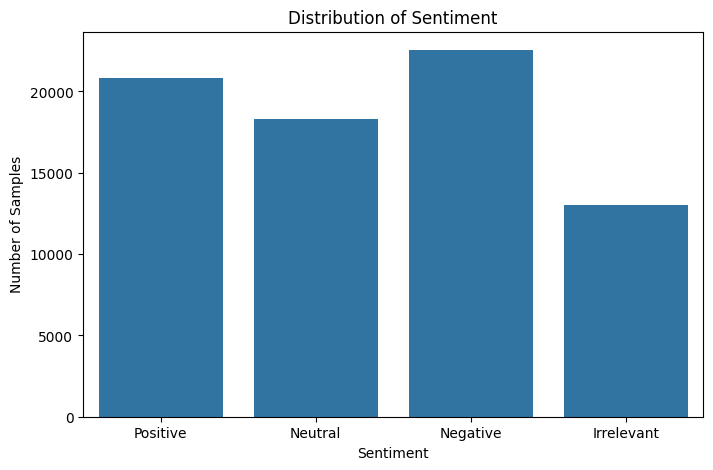

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sentiment")

plt.title("Distribution of Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
print(df.columns)
print(df["sentiment"].value_counts())

Index(['id', 'topic', 'sentiment', 'text'], dtype='object')
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


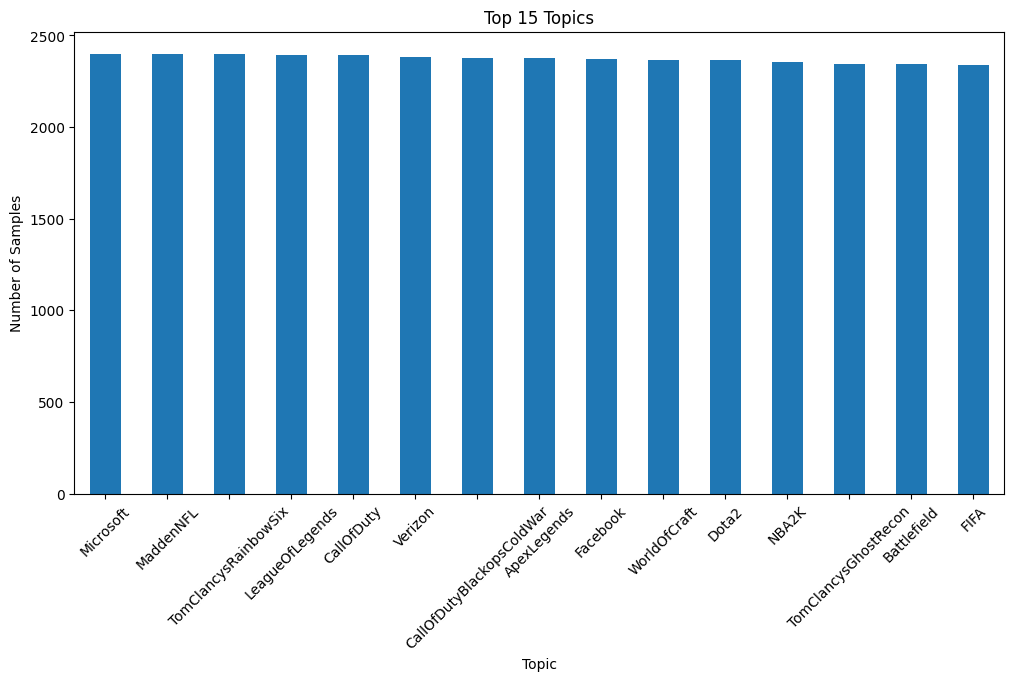

In [ ]:
plt.figure(figsize=(12, 6))

df["topic"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

In [ ]:
df["text_length"] = df["text"].astype(str).str.len()

print(df["text_length"].describe())

count    74682.000000
mean       107.811963
std         79.798839
min          1.000000
25%         45.000000
50%         90.000000
75%        152.000000
max        957.000000
Name: text_length, dtype: float64


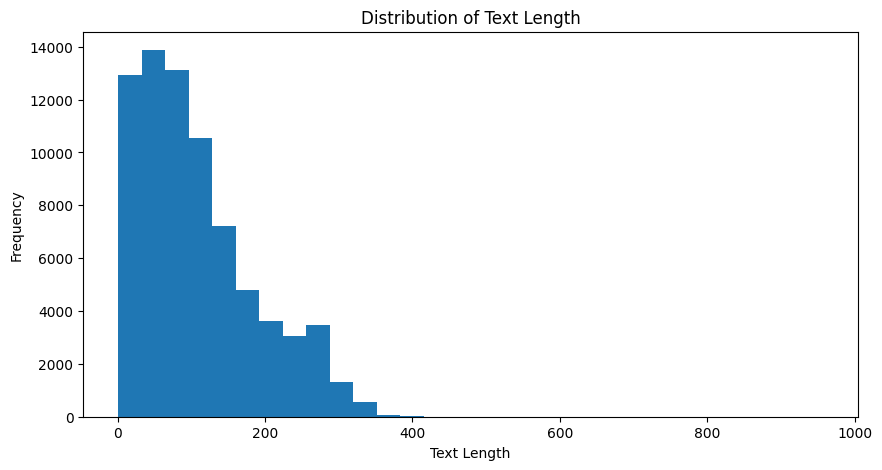

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(df["text_length"], bins=30)

plt.title("Distribution of Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
id               0
topic            0
sentiment        0
text           686
text_length      0
dtype: int64


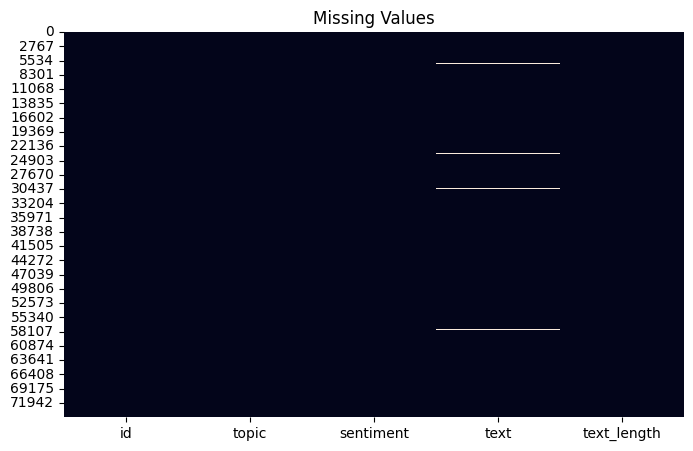

In [ ]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values")

plt.show()

**Bivariate Analysis**

In [ ]:
topic_sentiment = pd.crosstab(
    df["topic"],
    df["sentiment"]
)

print(topic_sentiment)

sentiment                          Irrelevant  Negative  Neutral  Positive
topic                                                                     
Amazon                                    192       576     1236       312
ApexLegends                               192       600      942       642
AssassinsCreed                            264       378      156      1446
Battlefield                               918       474      360       594
Borderlands                               240       426      600      1020
CS-GO                                     636       348      552       768
CallOfDuty                                672       894      378       450
CallOfDutyBlackopsColdWar                 576       576      360       864
Cyberpunk2077                             480       390      468       966
Dota2                                     426       768      588       582
FIFA                                      558      1176      102       504
Facebook                 

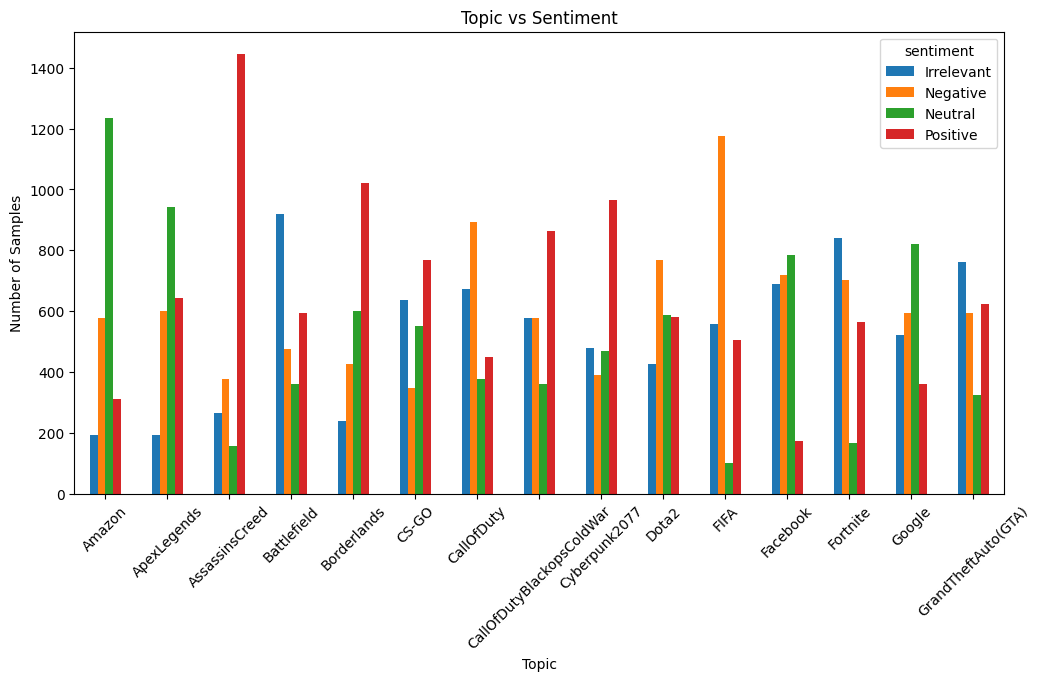

In [ ]:
topic_sentiment.head(15).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Topic vs Sentiment")
plt.xlabel("Topic")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

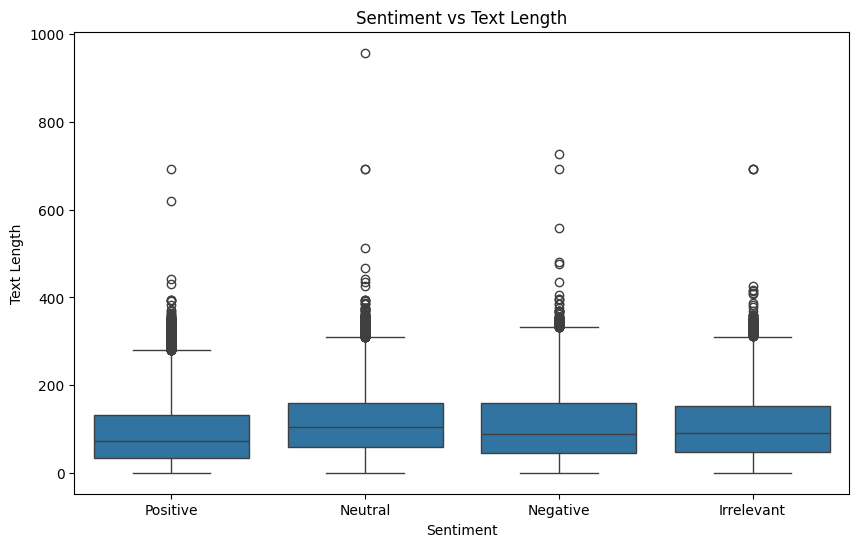

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="sentiment",
    y="text_length"
)

plt.title("Sentiment vs Text Length")
plt.xlabel("Sentiment")
plt.ylabel("Text Length")

plt.show()

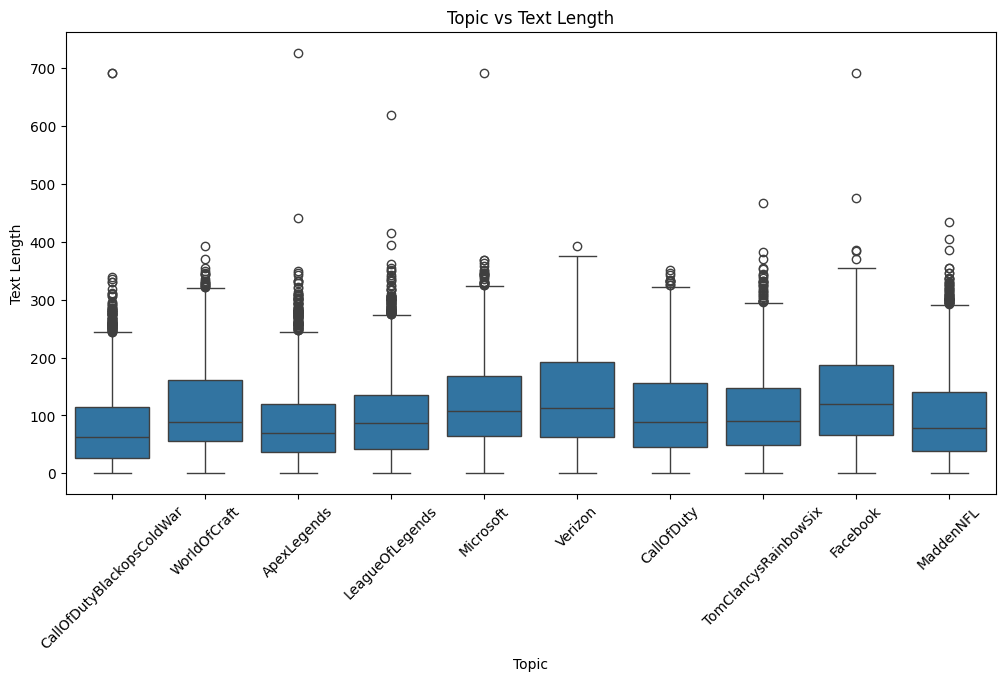

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[df["topic"].isin(
        df["topic"].value_counts().head(10).index
    )],
    x="topic",
    y="text_length"
)

plt.title("Topic vs Text Length")
plt.xlabel("Topic")
plt.ylabel("Text Length")
plt.xticks(rotation=45)

plt.show()

**Multivariate Analysis**

In [ ]:
multi_analysis = df.groupby(
    ["topic", "sentiment"]
)["text_length"].mean()

print(multi_analysis)

topic            sentiment 
Amazon           Irrelevant    119.041667
                 Negative      125.960069
                 Neutral       145.925566
                 Positive      104.304487
ApexLegends      Irrelevant     78.260417
                                  ...    
Xbox(Xseries)    Positive       88.796717
johnson&johnson  Irrelevant     85.515152
                 Negative      116.879433
                 Neutral       142.832347
                 Positive      127.277778
Name: text_length, Length: 128, dtype: float64


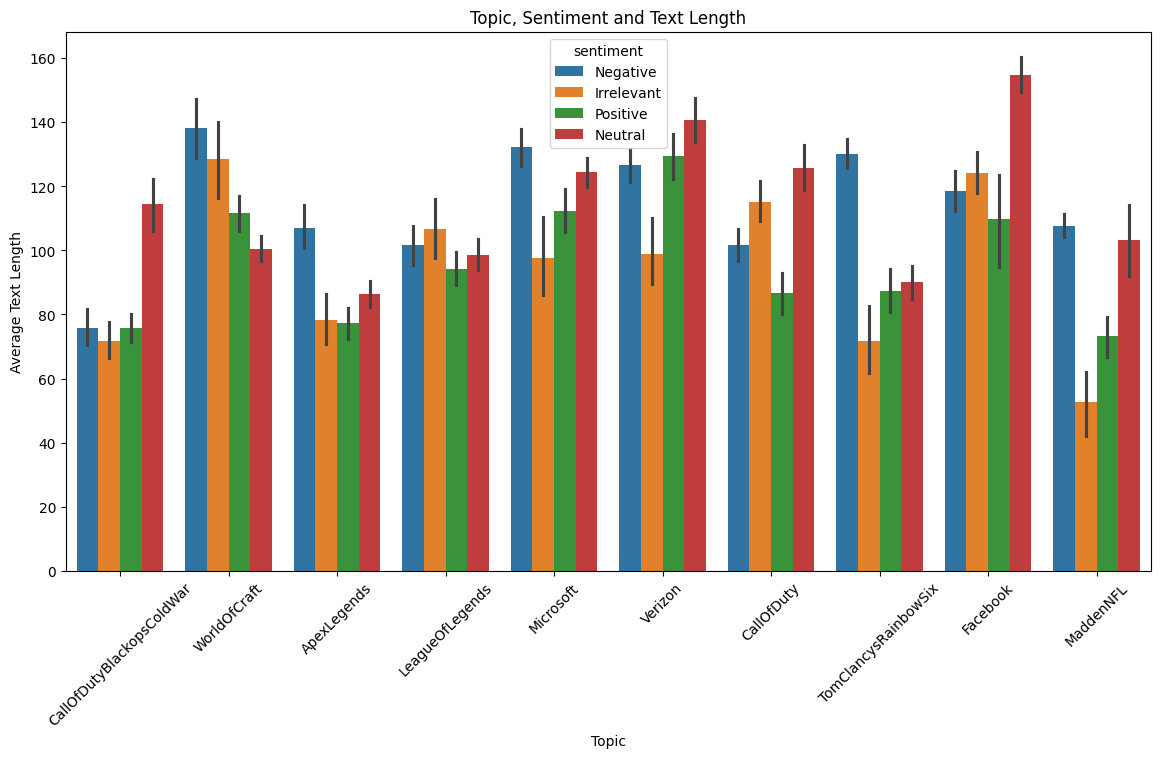

In [ ]:
top_topics = df["topic"].value_counts().head(10).index

temp = df[df["topic"].isin(top_topics)]

plt.figure(figsize=(14, 7))

sns.barplot(
    data=temp,
    x="topic",
    y="text_length",
    hue="sentiment"
)

plt.title("Topic, Sentiment and Text Length")
plt.xlabel("Topic")
plt.ylabel("Average Text Length")
plt.xticks(rotation=45)

plt.show()

In [ ]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_columns].corr()

print(correlation)

                   id  text_length
id           1.000000     0.012559
text_length  0.012559     1.000000


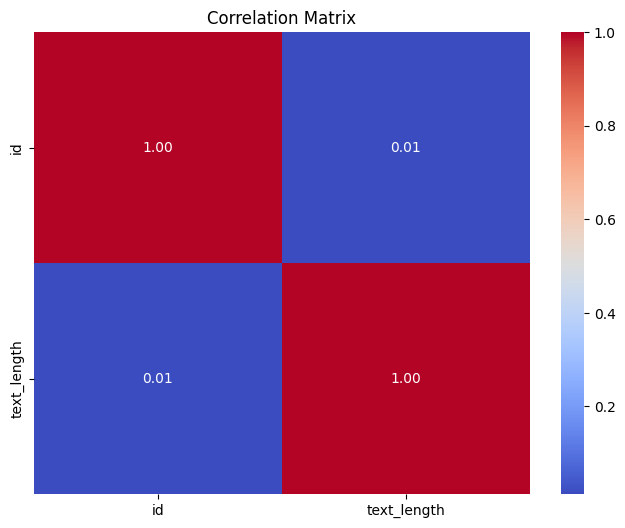

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

**Text Length vs Key Features**

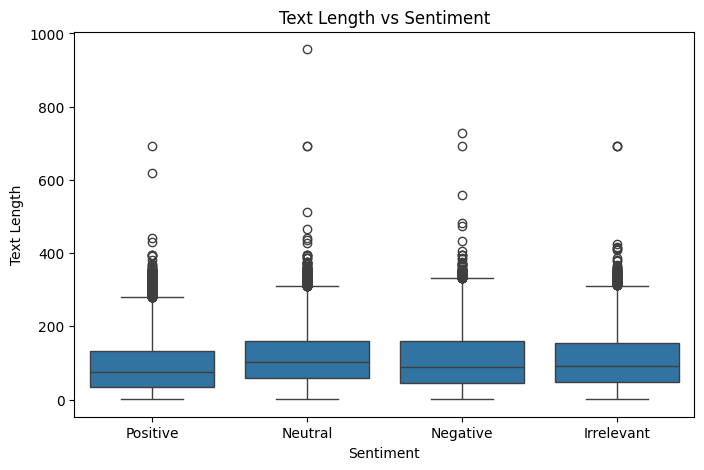

In [ ]:
df["text_length"] = df["text"].astype(str).str.len()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="sentiment",
    y="text_length"
)

plt.title("Text Length vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Text Length")

plt.show()

**Dataset Preprocessing**

**Reformatting**

In [ ]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip().str.lower()

# Remove leading/trailing spaces from text columns
text_columns = ["topic", "sentiment", "text"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Convert ID to numeric
df["id"] = pd.to_numeric(df["id"], errors="coerce")

print("Dataset after reformatting:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset after reformatting:
     id        topic sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  text_length  
0  im getting on borderlands and i will murder yo...           53  
1  I am coming to the borders and I will kill you...           51  
2  im getting on borderlands and i will kill you ...           50  
3  im coming on borderlands and i will murder you...           51  
4  im getting on borderlands 2 and i will murder ...           57  

Data Types:
id              int64
topic          object
sentiment      object
text           object
text_length     int64
dtype: object


**Handling Missing Values**

In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
id             0
topic          0
sentiment      0
text           0
text_length    0
dtype: int64


In [ ]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print("\nMissing Value Percentage:")
print(missing_percentage)


Missing Value Percentage:
id             0.0
topic          0.0
sentiment      0.0
text           0.0
text_length    0.0
dtype: float64


In [ ]:
# Remove rows where important columns are missing

df = df.dropna(
    subset=["topic", "sentiment", "text"]
)

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
id             0
topic          0
sentiment      0
text           0
text_length    0
dtype: int64


**Data Imputation**

In [ ]:
# Impute missing categorical values using mode

for col in ["topic", "sentiment"]:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(
            df[col].mode()[0]
        )

# Text missing values
df["text"] = df["text"].fillna("Unknown")

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
id             0
topic          0
sentiment      0
text           0
text_length    0
dtype: int64


**Data Transformation**

In [ ]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

print(df[["text", "clean_text"]].head())

                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                                          clean_text  
0  im getting on borderlands and i will murder yo...  
1  i am coming to the borders and i will kill you...  
2  im getting on borderlands and i will kill you all  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


**Automatic Outlier Removal**

In [ ]:
Q1 = df["text_length"].quantile(0.25)
Q3 = df["text_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Count outliers
outliers = df[
    (df["text_length"] < lower_bound) |
    (df["text_length"] > upper_bound)
]

print("\nNumber of Outliers:", len(outliers))

Q1: 45.0
Q3: 152.0
IQR: 107.0
Lower Bound: -115.5
Upper Bound: 312.5

Number of Outliers: 838


**One-Hot Encoding**

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["topic"],
    prefix="topic",
    dtype=int
)

print(df_encoded.head())

print("\nNew Columns:")
print(df_encoded.columns.tolist())

     id sentiment                                               text  \
0  2401  Positive  im getting on borderlands and i will murder yo...   
1  2401  Positive  I am coming to the borders and I will kill you...   
2  2401  Positive  im getting on borderlands and i will kill you ...   
3  2401  Positive  im coming on borderlands and i will murder you...   
4  2401  Positive  im getting on borderlands 2 and i will murder ...   

   text_length                                         clean_text  \
0           53  im getting on borderlands and i will murder yo...   
1           51  i am coming to the borders and i will kill you...   
2           50  im getting on borderlands and i will kill you all   
3           51  im coming on borderlands and i will murder you...   
4           57  im getting on borderlands 2 and i will murder ...   

   topic_Amazon  topic_ApexLegends  topic_AssassinsCreed  topic_Battlefield  \
0             0                  0                     0                 

**Feature Scaling**

**STANDARD SCALING**

In [ ]:
# Select numerical feature
numeric_features = ["text_length"]

# Create scaler
scaler = StandardScaler()

# Apply Standard Scaling
df[numeric_features] = scaler.fit_transform(
    df[numeric_features]
)

# Display result
print("After Standard Scaling:")
print(df[numeric_features].head())

# Check mean and standard deviation
print("\nMean:")
print(df[numeric_features].mean())

print("\nStandard Deviation:")
print(df[numeric_features].std())

After Standard Scaling:
   text_length
0    -0.686881
1    -0.711944
2    -0.724476
3    -0.711944
4    -0.636755

Mean:
text_length    1.179766e-17
dtype: float64

Standard Deviation:
text_length    1.000007
dtype: float64


In [ ]:
scaler = StandardScaler()

df["text_length_scaled"] = scaler.fit_transform(
    df[["text_length"]]
)

print(
    df[
        ["text_length", "text_length_scaled"]
    ].head()
)

   text_length  text_length_scaled
0    -0.686881           -0.686881
1    -0.711944           -0.711944
2    -0.724476           -0.724476
3    -0.711944           -0.711944
4    -0.636755           -0.636755


**Dataset Splitting**

In [ ]:
# Features and target
X = df["clean_text"]
y = df["sentiment"]

# Split dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nTraining Distribution:")
print(y_train.value_counts())

print("\nTesting Distribution:")
print(y_test.value_counts())

Training Samples: 59745
Testing Samples: 14937

Training Distribution:
sentiment
Negative      18033
Positive      16666
Neutral       14654
Irrelevant    10392
Name: count, dtype: int64

Testing Distribution:
sentiment
Negative      4509
Positive      4166
Neutral       3664
Irrelevant    2598
Name: count, dtype: int64


**Five-Fold Cross Validation**

In [ ]:
# Create 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold = 1

for train_index, validation_index in skf.split(
    X_train,
    y_train
):

    X_fold_train = X_train.iloc[train_index]
    X_fold_validation = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_validation = y_train.iloc[validation_index]

    print(f"\nFold {fold}")

    print(
        "Training samples:",
        len(X_fold_train)
    )

    print(
        "Validation samples:",
        len(X_fold_validation)
    )

    fold += 1


Fold 1
Training samples: 47796
Validation samples: 11949

Fold 2
Training samples: 47796
Validation samples: 11949

Fold 3
Training samples: 47796
Validation samples: 11949

Fold 4
Training samples: 47796
Validation samples: 11949

Fold 5
Training samples: 47796
Validation samples: 11949


**Model Training and Testing**

In [ ]:
X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 59745
Testing samples: 14937


**TF-IDF FEATURE EXTRACTION**

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_tfidf.shape)

Training TF-IDF Shape: (59745, 5000)
Testing TF-IDF Shape: (14937, 5000)


**Logistic Regression**

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(
    X_test_tfidf
)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_pred
    )
)

Logistic Regression Accuracy: 0.6755707304010176

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.66      0.50      0.57      2598
    Negative       0.72      0.77      0.74      4509
     Neutral       0.62      0.63      0.62      3664
    Positive       0.69      0.73      0.71      4166

    accuracy                           0.68     14937
   macro avg       0.67      0.66      0.66     14937
weighted avg       0.67      0.68      0.67     14937



**Naïve Bayes**

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nb_pred
    )
)

Naive Bayes Accuracy: 0.6206065474994978

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.71      0.30      0.42      2598
    Negative       0.60      0.79      0.69      4509
     Neutral       0.63      0.51      0.56      3664
    Positive       0.62      0.73      0.67      4166

    accuracy                           0.62     14937
   macro avg       0.64      0.58      0.59     14937
weighted avg       0.63      0.62      0.61     14937



**K-Nearest Neighbor**

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_tfidf,
    y_train
)

knn_pred = knn_model.predict(
    X_test_tfidf
)

print("KNN Accuracy:",
      accuracy_score(y_test, knn_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        knn_pred
    )
)

KNN Accuracy: 0.8529155787641427

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.85      0.82      0.83      2598
    Negative       0.87      0.88      0.87      4509
     Neutral       0.82      0.85      0.84      3664
    Positive       0.87      0.84      0.86      4166

    accuracy                           0.85     14937
   macro avg       0.85      0.85      0.85     14937
weighted avg       0.85      0.85      0.85     14937



**Support Vector Machine**

In [ ]:
svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svm_pred
    )
)

SVM Accuracy: 0.6876882908214501

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.67      0.54      0.60      2598
    Negative       0.73      0.76      0.75      4509
     Neutral       0.63      0.65      0.64      3664
    Positive       0.70      0.74      0.72      4166

    accuracy                           0.69     14937
   macro avg       0.68      0.67      0.68     14937
weighted avg       0.69      0.69      0.69     14937



**Decision Trees**

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    X_train_tfidf,
    y_train
)

dt_pred = dt_model.predict(
    X_test_tfidf
)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_pred
    )
)

Decision Tree Accuracy: 0.7287942692642432

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.71      0.63      0.67      2598
    Negative       0.77      0.76      0.77      4509
     Neutral       0.68      0.75      0.71      3664
    Positive       0.75      0.74      0.74      4166

    accuracy                           0.73     14937
   macro avg       0.73      0.72      0.72     14937
weighted avg       0.73      0.73      0.73     14937



**Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf_model.predict(
    X_test_tfidf
)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.861752694650867

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.96      0.75      0.84      2598
    Negative       0.86      0.90      0.87      4509
     Neutral       0.82      0.88      0.85      3664
    Positive       0.86      0.88      0.87      4166

    accuracy                           0.86     14937
   macro avg       0.87      0.85      0.86     14937
weighted avg       0.87      0.86      0.86     14937



**Model Comparison Analysis**

In [ ]:
models = {
    "Logistic Regression": lr_pred,
    "Naive Bayes": nb_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred
}

**Comparison of Mean Accuracy**

In [ ]:
# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Fast models
model_list = {
    "Logistic Regression": LogisticRegression(
        max_iter=500
    ),

    "Naive Bayes": MultinomialNB(),

    "SVM": LinearSVC(
        random_state=42
    )
}

mean_accuracy_results = []

for name, model in model_list.items():

    print(f"\nRunning: {name}")

    pipeline = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=3000,
                ngram_range=(1, 2)
            )
        ),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    mean_accuracy_results.append({
        "Model": name,
        "Fold 1": scores[0] * 100,
        "Fold 2": scores[1] * 100,
        "Fold 3": scores[2] * 100,
        "Fold 4": scores[3] * 100,
        "Fold 5": scores[4] * 100,
        "Mean Accuracy": scores.mean() * 100
    })

mean_accuracy_df = pd.DataFrame(
    mean_accuracy_results
)

# Round values
accuracy_columns = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5",
    "Mean Accuracy"
]

mean_accuracy_df[accuracy_columns] = (
    mean_accuracy_df[accuracy_columns].round(2)
)

print("\n5-Fold Cross Validation Results:")
print(mean_accuracy_df)


Running: Logistic Regression

Running: Naive Bayes

Running: SVM

5-Fold Cross Validation Results:
                 Model  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean Accuracy
0  Logistic Regression   61.79   62.59   62.44   62.63   62.69          62.43
1          Naive Bayes   58.18   58.63   58.31   58.24   58.26          58.32
2                  SVM   62.31   63.12   62.53   62.97   62.68          62.72


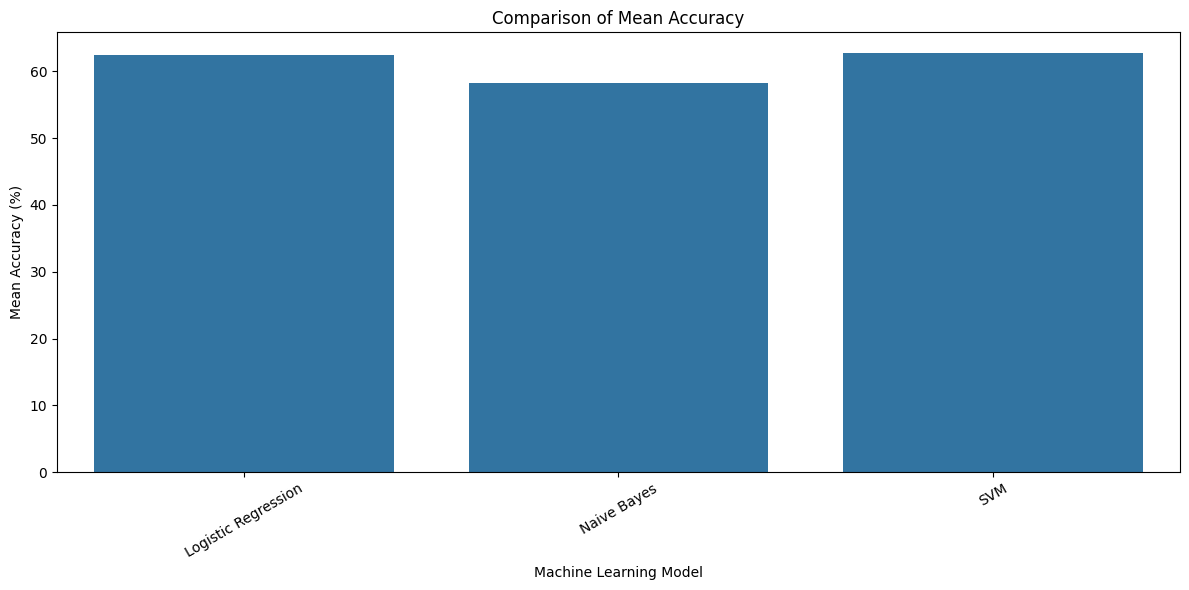

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=mean_accuracy_df,
    x="Model",
    y="Mean Accuracy"
)

plt.title("Comparison of Mean Accuracy")
plt.xlabel("Machine Learning Model")
plt.ylabel("Mean Accuracy (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Classification Report**

In [ ]:
for model_name, predictions in models.items():

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

  Irrelevant       0.66      0.50      0.57      2598
    Negative       0.72      0.77      0.74      4509
     Neutral       0.62      0.63      0.62      3664
    Positive       0.69      0.73      0.71      4166

    accuracy                           0.68     14937
   macro avg       0.67      0.66      0.66     14937
weighted avg       0.67      0.68      0.67     14937


Naive Bayes
              precision    recall  f1-score   support

  Irrelevant       0.71      0.30      0.42      2598
    Negative       0.60      0.79      0.69      4509
     Neutral       0.63      0.51      0.56      3664
    Positive       0.62      0.73      0.67      4166

    accuracy                           0.62     14937
   macro avg       0.64      0.58      0.59     14937
weighted avg       0.63      0.62      0.61     14937


KNN
              precision    recall  f1-score   support

  Irrelevant       0.85      0.82   

In [ ]:
from sklearn.metrics import f1_score

f1_results = []

for model_name, predictions in models.items():

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1_results.append({
        "Model": model_name,
        "Weighted F1 Score": f1
    })

f1_df = pd.DataFrame(f1_results)

f1_df["Weighted F1 Score"] = (
    f1_df["Weighted F1 Score"] * 100
).round(2)

print(f1_df)

                 Model  Weighted F1 Score
0  Logistic Regression              67.25
1          Naive Bayes              60.51
2                  KNN              85.29
3                  SVM              68.58
4        Decision Tree              72.84
5        Random Forest              86.14


**Confusion Matrix**

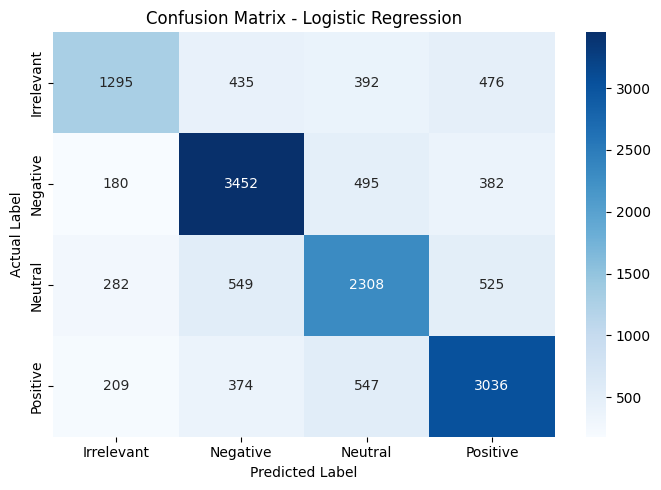

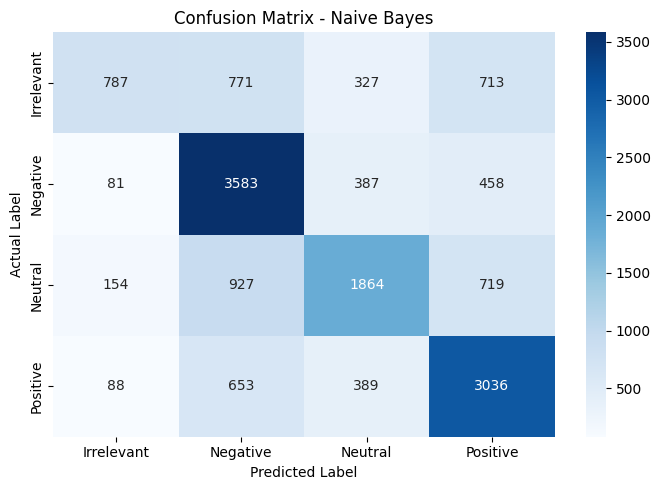

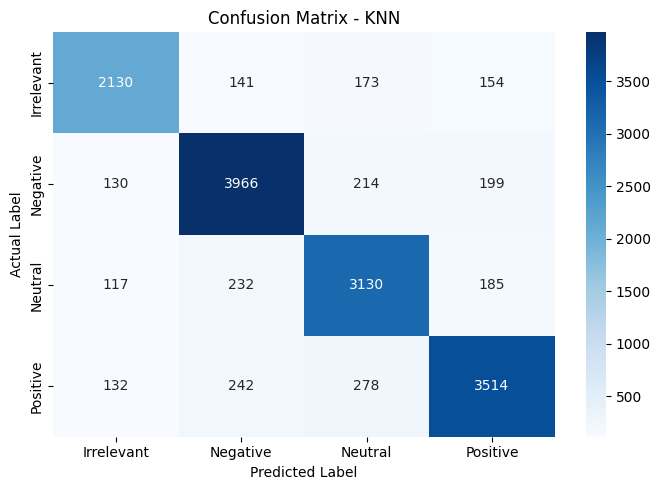

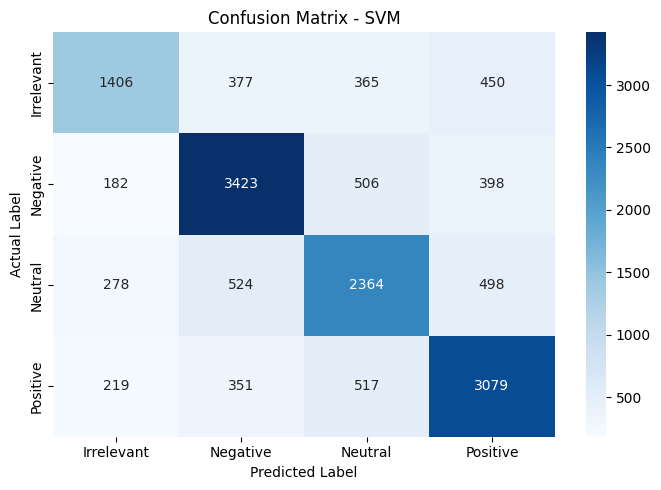

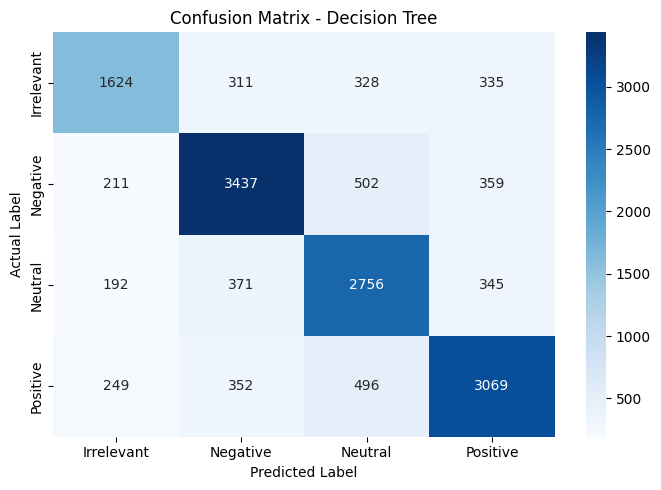

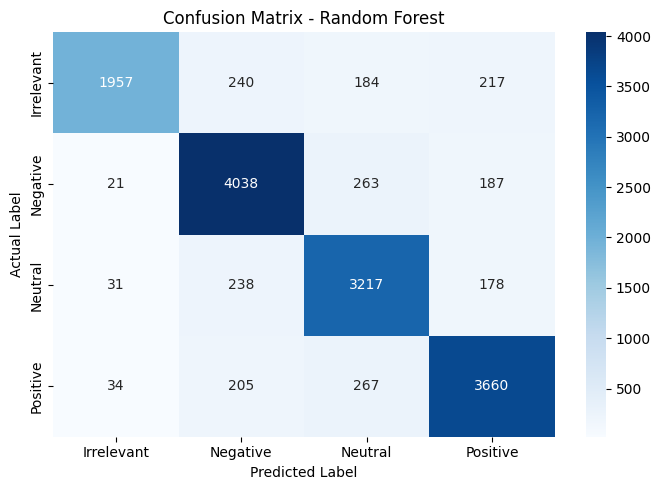

In [ ]:
for model_name, predictions in models.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=sorted(y_test.unique())
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=sorted(y_test.unique()),
        yticklabels=sorted(y_test.unique())
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()

**Normalized Confusion Matrix**

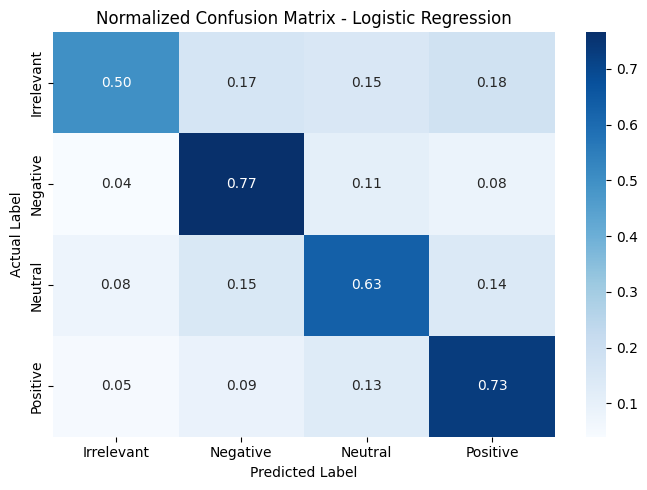

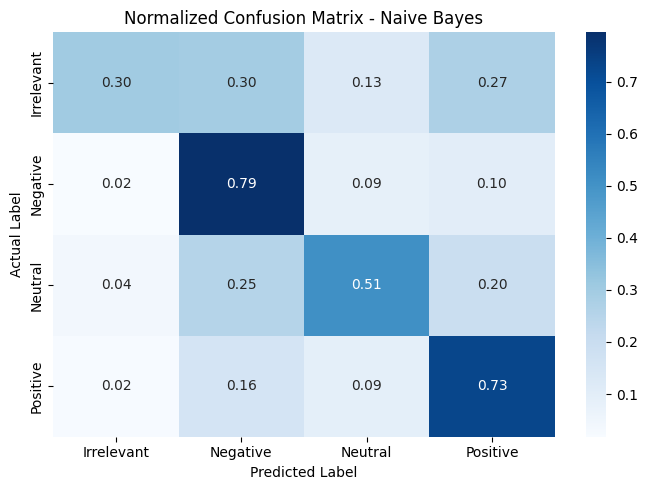

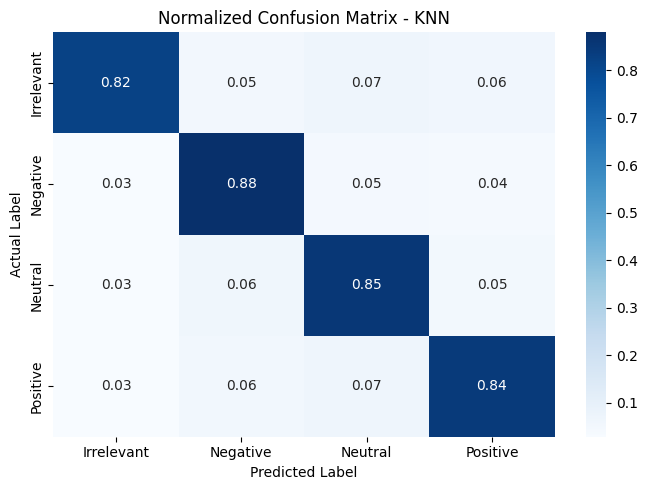

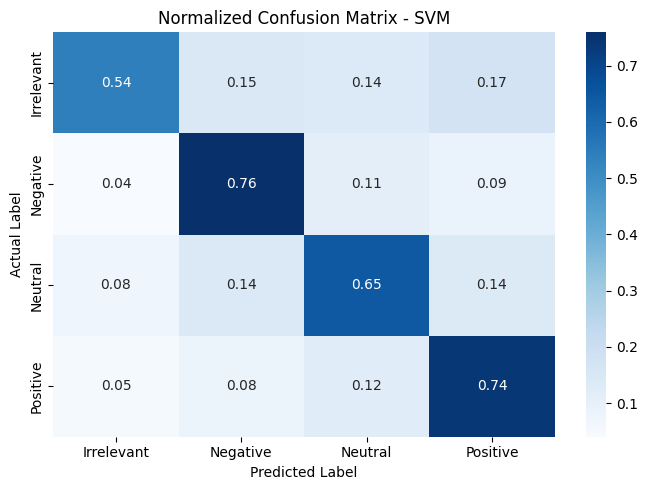

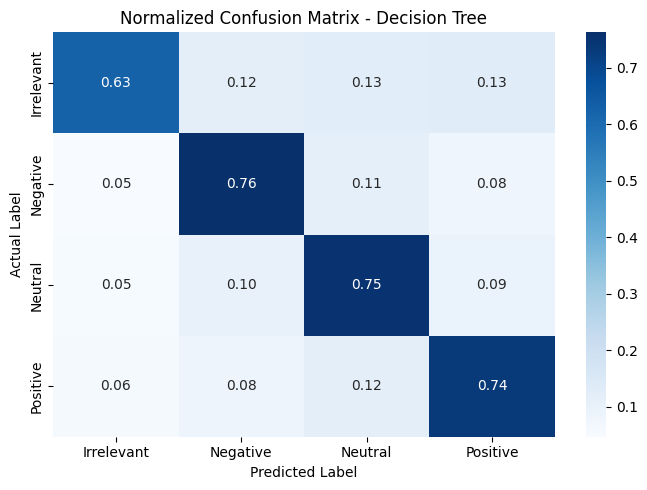

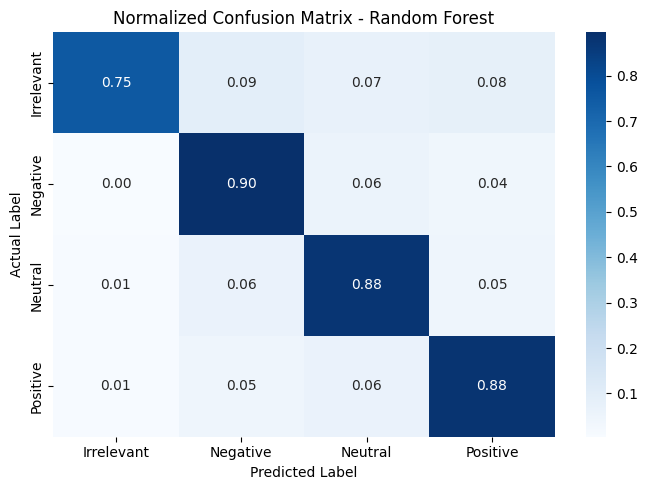

In [ ]:
for model_name, predictions in models.items():

    cm = confusion_matrix(
        y_test,
        predictions,
        normalize="true"
    )

    plt.figure(figsize=(7, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=sorted(y_test.unique()),
        yticklabels=sorted(y_test.unique())
    )

    plt.title(
        f"Normalized Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.tight_layout()
    plt.show()